Device : cpu
Save   : /srv/johan/Course work/Biologically Informed Neural Networks/Heart_ST

══════════════════════════════════════════════════════════════════════
PART 1: Preprocess scRNA-seq
══════════════════════════════════════════════════════════════════════
  Total      : 114,555
  Barcoded   : 75,738 (66.1%)
  Unbarcoded : 38,817 (33.9%)

── Clone2vec ────────────────────────────────────────────────────────
SG epochs:  14%|█▍        | 71/500 [06:05<36:48,  5.15s/it, loss=5.4262, Δ=7.96e-05]
early stopping at epoch 72
  Lineage clusters: 33

── Biological feature scoring ───────────────────────────────────────


2026-03-17 08:19:32 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-17 08:19:36 | [INFO] 0001 gene_sets have been filtered out when max_size=2000 and min_size=0


  X_tf      : (114555, 259)
  X_pathway : (114555, 14)
  X_go      : (114555, 2457)

  Lineage classes  : 32
  Barcoded cells   : 61,290


... storing 'orig.ident' as categorical
... storing 'doublet_finder' as categorical
... storing 'Phase' as categorical
... storing 'cellid' as categorical
... storing 'predicted.id' as categorical
... storing 'predicted.celltype' as categorical
... storing 'scrublet_group' as categorical
... storing 'sample' as categorical
... storing 'cloneid' as categorical
... storing 'cellid.old' as categorical


  Saved preprocessing outputs.

══════════════════════════════════════════════════════════════════════
PART 2: Simulate ST spots from scRNA-seq
══════════════════════════════════════════════════════════════════════
  Barcoded   : 61,290 cells available for mixing
  Unbarcoded : 53,265 cells available for mixing
  Generating 55,000 pseudo-spots...

  Generating 50,000 training spots...
    10,000 / 50,000
    20,000 / 50,000
    30,000 / 50,000
    40,000 / 50,000
    50,000 / 50,000

  Generating 5,000 validation spots...

  Training spot statistics:
    Mean lineages per spot    : 1.93
    Pure spots (1 lineage)    : 49.8%
    Mixed spots (2+ lineages) : 50.2%
    Mean barcoded fraction    : 0.565

══════════════════════════════════════════════════════════════════════
PART 3: Model
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
PART 4: Train BINNDeconv
══════════════════════════════════════

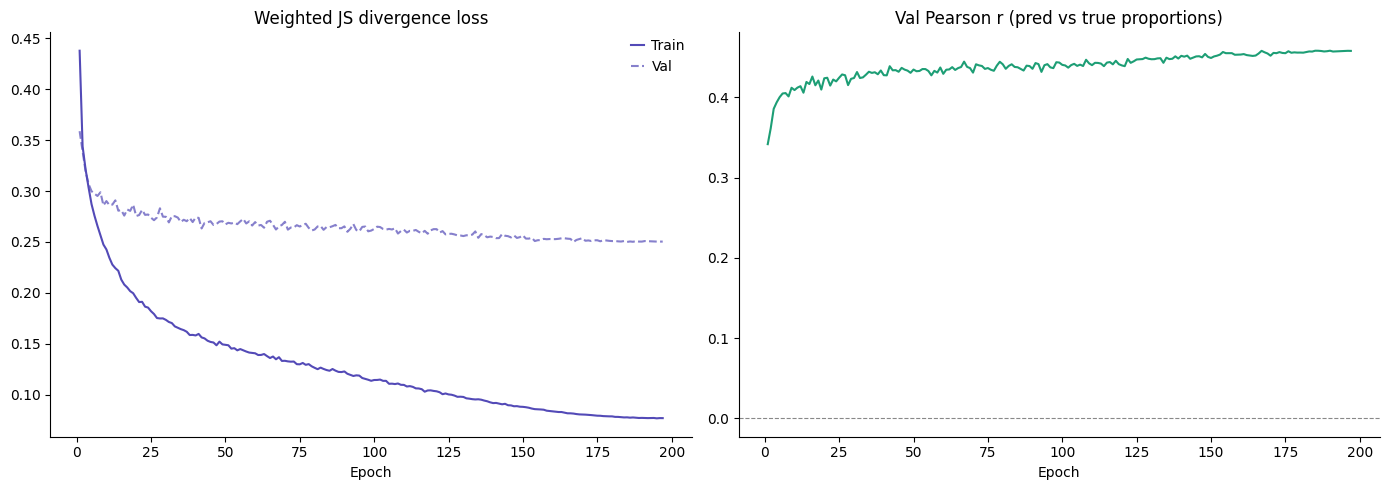

  Saved: binn_st_deconv.pt

══════════════════════════════════════════════════════════════════════
PART 5: Prepare ST data
══════════════════════════════════════════════════════════════════════
  ST: 59,767 spots × 11,031 genes
  ST ∩ reference: 3269 / 4329

  DoRothEA ULM...
  PROGENy MLM...
  AUCell GO...
  Dimension checks passed.
  Shared: 3269/4329 (75.5%)
  Final: 59,767 spots × 4,329 genes

══════════════════════════════════════════════════════════════════════
PART 6: Infer on ST
══════════════════════════════════════════════════════════════════════


... storing 'dominant_lineage' as categorical


  Inference complete: (59767, 32)
  Sums to 1: True

  Spot mixture statistics:
    Pure spots (1 lineage)    : 42,090 (70.4%)
    Mixed spots (2 lineages)  : 13,799 (23.1%)
    Complex (3+ lineages)     : 3,878 (6.5%)
    Mean lineages per spot    : 1.37
    Mean dominant confidence  : 0.917

── Visualisation ────────────────────────────────────────────────────


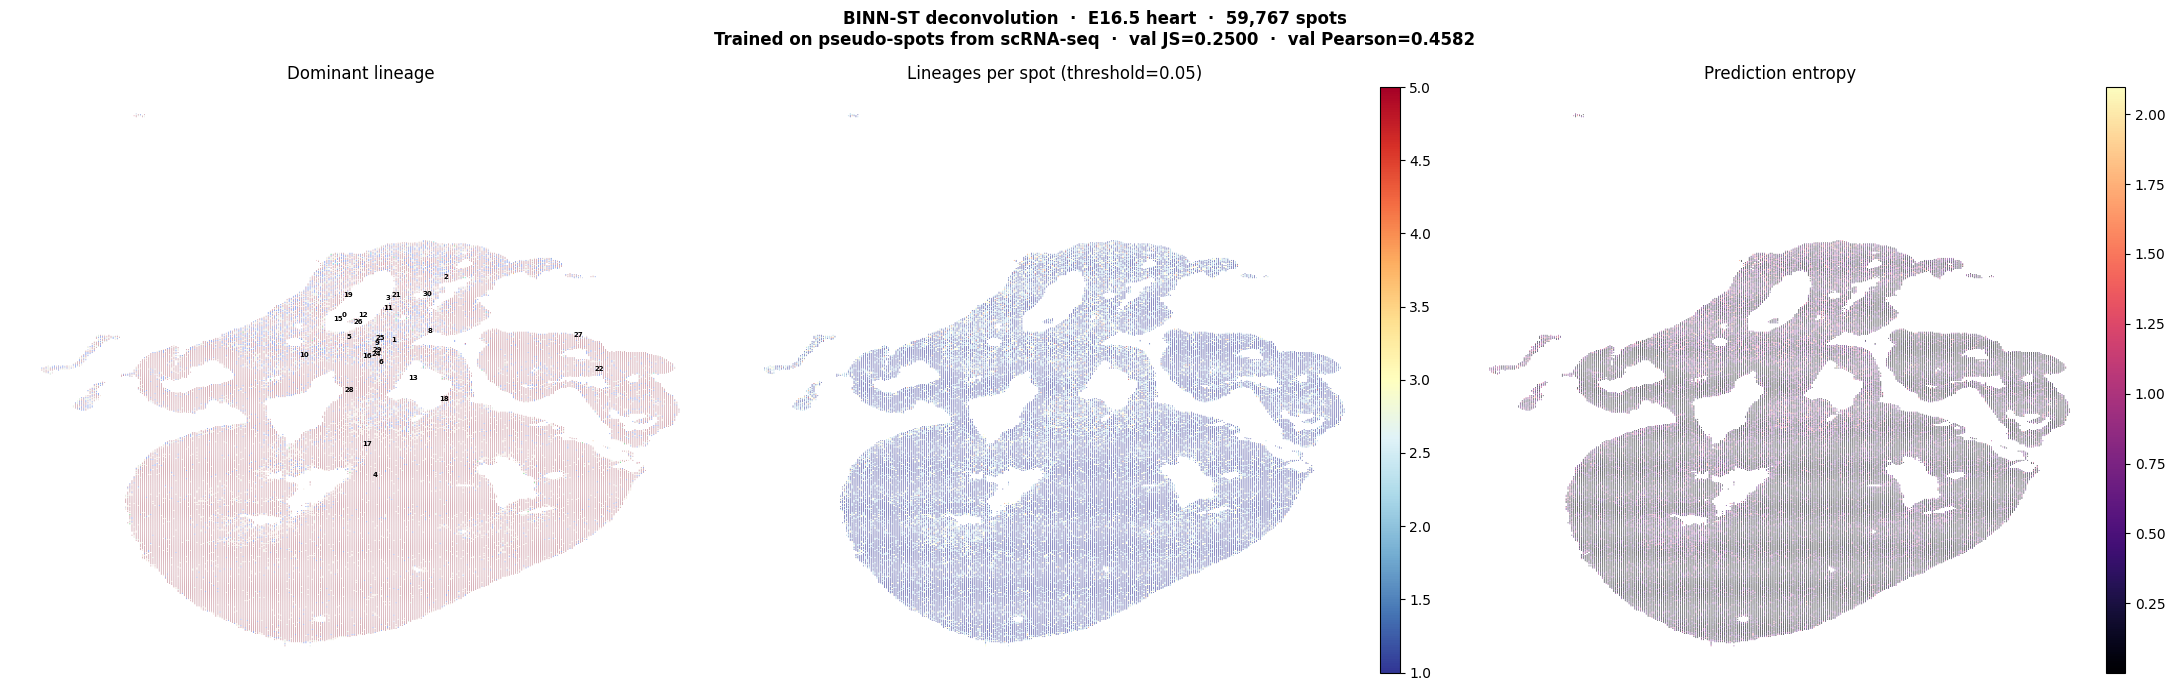

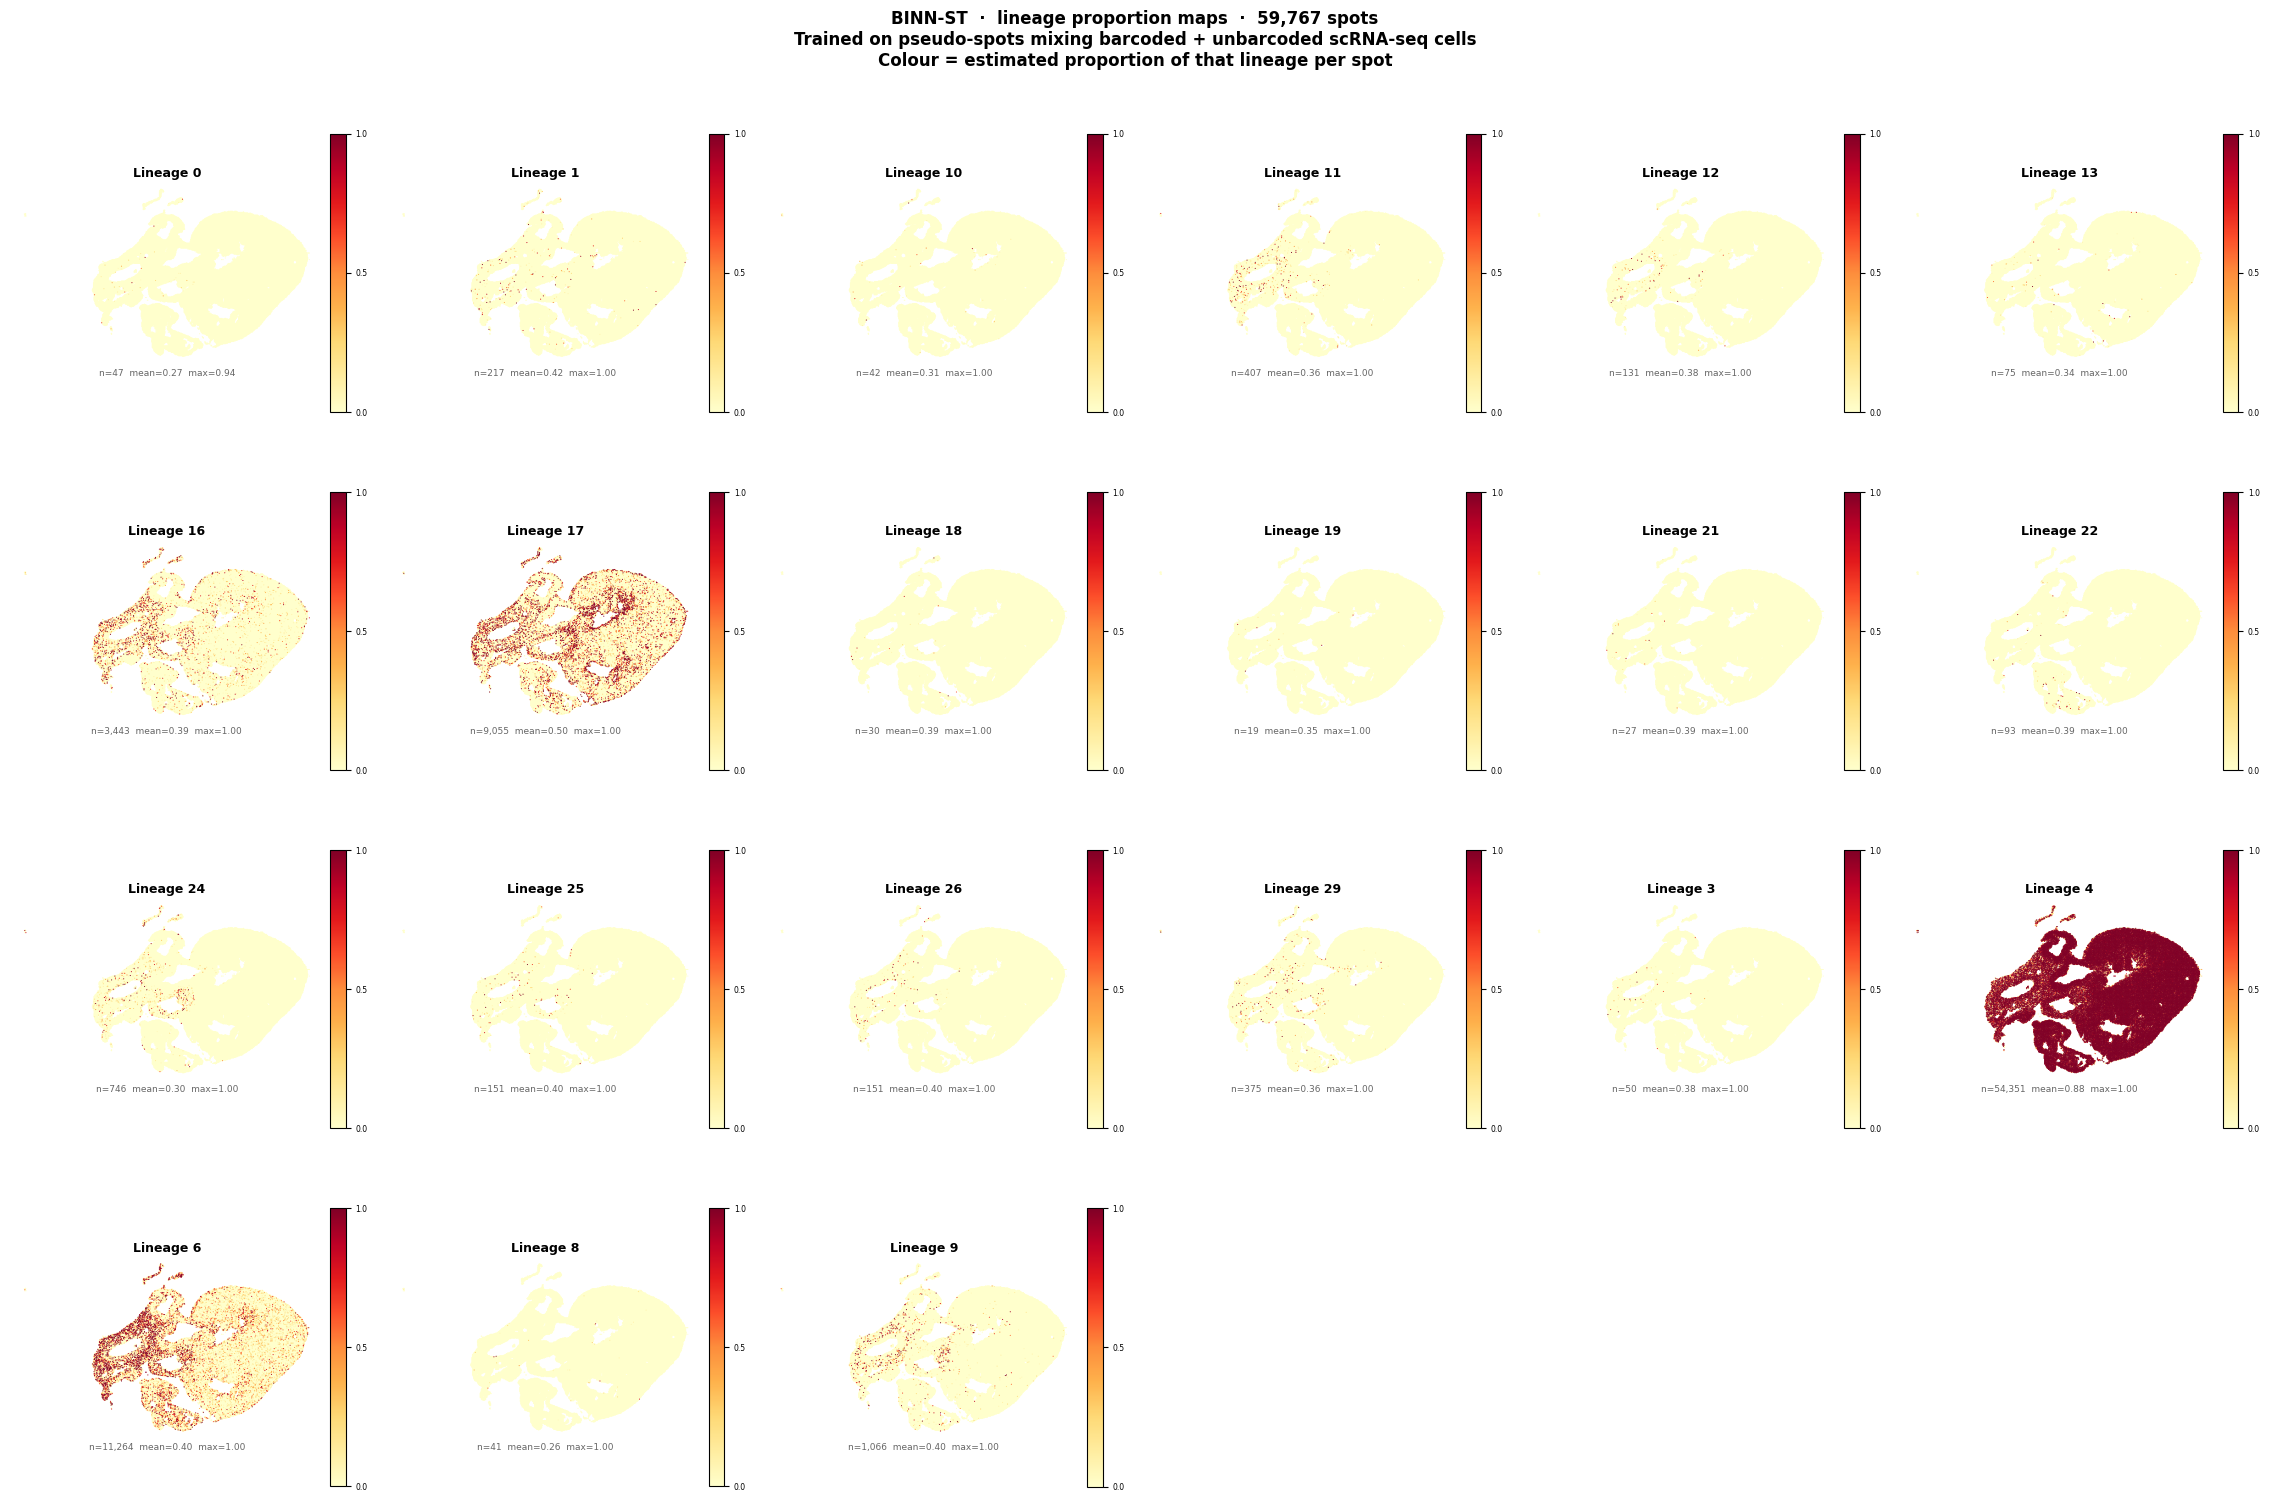

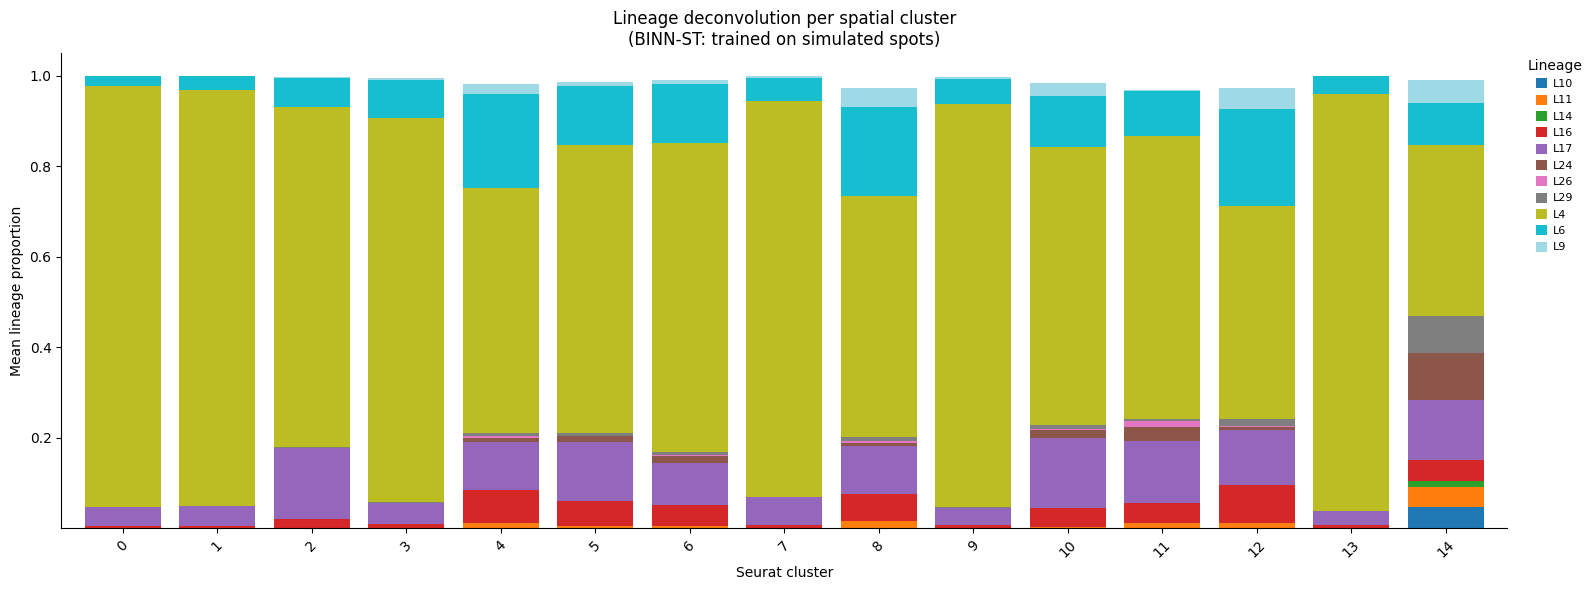


── Save ─────────────────────────────────────────────────────────────
  Saved: /srv/johan/Course work/Biologically Informed Neural Networks/Heart_ST/E16EXC_ST_HEART1_binn_st.h5ad
  Saved: ST_binn_proportions.csv

══════════════════════════════════════════════════════════════════════
DONE — BINN-ST pipeline complete
  Val JS loss    : 0.2500
  Val Pearson r  : 0.4582
  ST output      : /srv/johan/Course work/Biologically Informed Neural Networks/Heart_ST/E16EXC_ST_HEART1_binn_st.h5ad
══════════════════════════════════════════════════════════════════════


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# BINN-ST: Spatially-Aware BINN
# Trains on scRNA-seq by simulating ST spots → infers directly on ST data
# Key idea: model learns to handle mixed spot-level expression during training
# so ST inference is in-distribution rather than out-of-distribution
# ══════════════════════════════════════════════════════════════════════════════

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CONFIG                                                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
DATA_PATH  = "/srv/johan/Python/E16 Heart Data/data/E16EXC_CLONEID_ONLY.h5ad"
ST_PATH    = "E16EXC_ST_HEART1.h5ad"
SAVE_DIR   = "/srv/johan/Course work/Biologically Informed Neural Networks/Heart_ST"

# ── Clone2vec ─────────────────────────────────────────────────────────────────
MIN_CLONE_SIZE  = 5
C2V_RESOLUTION  = 3.0
C2V_BATCH_SIZE  = 4096
C2V_PATIENCE    = 3
CLONEID_COL     = "cloneid"
CLONEID_NA_INT  = -2147483648
CLUSTER_KEY     = "seurat_clusters"
CELLTYPE_KEY    = "seurat_clusters"
UMAP_KEY        = "X_umap_sct_rpca"
PCA_KEY         = "X_pca"

# ── Biology ───────────────────────────────────────────────────────────────────
ORGANISM        = "mouse"
TF_CONFIDENCE   = ["A", "B", "C"]
PROGENY_TOP     = 500
GO_LIBRARY      = "GO_Biological_Process_2023"
GO_ORGANISM     = "Mouse"
GO_MIN_SIZE     = 10
GO_MAX_SIZE     = 500

# ── Pseudo-spot simulation ────────────────────────────────────────────────────
# This is the core of the approach — we simulate ST spots from scRNA-seq
# by mixing cells with known lineage compositions
N_PSEUDO_SPOTS      = 50000  # total synthetic spots
N_PSEUDO_SPOTS_VAL  = 5000   # held-out synthetic spots for validation
# Cells per spot distribution — realistic for 8µm Stereo-seq
# Weighted toward 2-4 cells per spot
CELLS_PER_SPOT_DIST = [1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 6, 7, 8]
# Fraction of barcoded cells in a typical spot
# At E16.5 heart with flow sorting, ~20-40% of cells are barcoded
# This models the dilution of lineage signal by unlabelled cells
BARCODED_FRAC_RANGE = (0.1, 0.9)   # min/max barcoded fraction per spot
# Dirichlet concentration — lower = spikier mixtures (more pure spots)
DIRICHLET_ALPHA     = 0.5

# ── Model ─────────────────────────────────────────────────────────────────────
TOKEN_DIM   = 128
Z_LINEAGE   = 64
N_EPOCHS    = 200
BATCH_SIZE  = 256
LR          = 1e-3
PATIENCE    = 30
MIN_EPOCHS  = 50
VAL_FRAC    = 0.1   # fraction of pseudo spots held out

# ── Inference ─────────────────────────────────────────────────────────────────
MIN_PROP        = 0.05   # threshold for reporting lineage as present in spot
CONF_THRESHOLD  = 0.5    # dominant lineage confidence threshold
RANDOM_SEED     = 42

# ══════════════════════════════════════════════════════════════════════════════
# Imports
# ══════════════════════════════════════════════════════════════════════════════
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import sclitr as sl
import decoupler as dc
import gseapy as gp
import torch
import torch.nn as nn
import anndata as ad
import matplotlib.pyplot as plt
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, random_split
from scipy.sparse import issparse, csr_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

os.makedirs(SAVE_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng    = np.random.default_rng(RANDOM_SEED)
print(f"Device : {device}")
print(f"Save   : {SAVE_DIR}")

# ══════════════════════════════════════════════════════════════════════════════
# PART 1 — Preprocessing (identical to BINN_Preprocessing_v2)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("PART 1: Preprocess scRNA-seq")
print("═"*70)

# ── Load ──────────────────────────────────────────────────────────────────────
adata = sc.read_h5ad(DATA_PATH)
adata.var_names_make_unique()

for col in [CLONEID_COL, CLUSTER_KEY]:
    if col not in adata.obs.columns:
        raise ValueError(f"Missing column: {col}")
for key in [UMAP_KEY, PCA_KEY]:
    if key not in adata.obsm:
        raise ValueError(f"Missing obsm key: {key}")

cloneid = adata.obs[CLONEID_COL]
if cloneid.dtype.name in ["int32", "int64", "Int32", "Int64"]:
    adata.obs[CLONEID_COL] = (cloneid.replace(CLONEID_NA_INT, pd.NA)
                               .astype("Int64").astype(str).replace("<NA>", "NA"))
else:
    adata.obs[CLONEID_COL] = (cloneid.astype(str)
                               .replace(str(CLONEID_NA_INT), "NA")
                               .replace("nan", "NA").replace("<NA>", "NA")
                               .replace("None", "NA"))

n_barcoded   = (adata.obs[CLONEID_COL] != "NA").sum()
n_unbarcoded = (adata.obs[CLONEID_COL] == "NA").sum()
print(f"  Total      : {adata.n_obs:,}")
print(f"  Barcoded   : {n_barcoded:,} ({n_barcoded/adata.n_obs*100:.1f}%)")
print(f"  Unbarcoded : {n_unbarcoded:,} ({n_unbarcoded/adata.n_obs*100:.1f}%)")

# ── Clone2vec ─────────────────────────────────────────────────────────────────
print(f"\n── Clone2vec ────────────────────────────────────────────────────────")
clones = sl.pp.clones_adata(adata, obs_name=CLONEID_COL,
                              fill_obs=CLUSTER_KEY,
                              min_size=MIN_CLONE_SIZE, na_value="NA")
sl.tl.clonal_nn(adata, clones, use_rep=PCA_KEY)
sl.tl.clone2vec(clones, batch_size=C2V_BATCH_SIZE,
                 early_stopping_patience=C2V_PATIENCE)
sc.pp.neighbors(clones, use_rep="clone2vec")
sc.tl.umap(clones)
sc.tl.leiden(clones, resolution=C2V_RESOLUTION,
             flavor="igraph", n_iterations=2)
sl.pp.transfer_annotation(adata, clones, annotation_obs_clones="leiden",
                           obs_name=CLONEID_COL, na_value="NA")
print(f"  Lineage clusters: {adata.obs['c2v_leiden'].nunique()}")

# ── Biological feature scoring ────────────────────────────────────────────────
print("\n── Biological feature scoring ───────────────────────────────────────")
net_tf      = dc.op.dorothea(organism=ORGANISM, levels=TF_CONFIDENCE)
net_pathway = dc.op.progeny(organism=ORGANISM, top=PROGENY_TOP)
dc.mt.ulm(adata, net=net_tf, verbose=False)
dc.mt.mlm(adata, net=net_pathway, verbose=False)
adata.obsm["X_tf"]       = adata.obsm["score_ulm"].values.astype(np.float32)
adata.obsm["X_pathway"]  = adata.obsm["score_mlm"].values.astype(np.float32)
adata.uns["tf_names"]    = list(adata.obsm["score_ulm"].columns)
adata.uns["pathway_names"] = list(adata.obsm["score_mlm"].columns)

gene_sets_raw = gp.get_library(GO_LIBRARY, organism=GO_ORGANISM)
gene_sets     = {k: v for k, v in gene_sets_raw.items()
                 if GO_MIN_SIZE <= len(v) <= GO_MAX_SIZE}
go_rows = []
for term, genes in gene_sets.items():
    for g in genes:
        g_conv = g[0].upper() + g[1:].lower()
        if g_conv in adata.var_names:
            go_rows.append({"source": term, "target": g_conv, "weight": 1.0})
go_net = pd.DataFrame(go_rows)
dc.mt.aucell(adata, net=go_net, verbose=False)
adata.obsm["X_go"]    = adata.obsm["score_aucell"].values.astype(np.float32)
adata.uns["go_names"] = list(adata.obsm["score_aucell"].columns)
print(f"  X_tf      : {adata.obsm['X_tf'].shape}")
print(f"  X_pathway : {adata.obsm['X_pathway'].shape}")
print(f"  X_go      : {adata.obsm['X_go'].shape}")

# ── Encode labels ─────────────────────────────────────────────────────────────
barcoded_mask = adata.obs["c2v_leiden"] != "NA"
le_lineage    = LabelEncoder()
adata.obs["lineage_code"] = -1
adata.obs.loc[barcoded_mask, "lineage_code"] = le_lineage.fit_transform(
    adata.obs.loc[barcoded_mask, "c2v_leiden"].astype(str))
n_lineages = len(le_lineage.classes_)
print(f"\n  Lineage classes  : {n_lineages}")
print(f"  Barcoded cells   : {barcoded_mask.sum():,}")

# ── Save ──────────────────────────────────────────────────────────────────────
dims = {
    "n_genes":        adata.n_vars,
    "n_tfs":          adata.obsm["X_tf"].shape[1],
    "n_pathways":     adata.obsm["X_pathway"].shape[1],
    "n_go":           adata.obsm["X_go"].shape[1],
    "n_lineages":     n_lineages,
    "min_clone_size": int(MIN_CLONE_SIZE),
    "c2v_resolution": float(C2V_RESOLUTION),
}
for key in ["le_lineage", "le_celltype", "clonal_nn", "clone2vec"]:
    adata.uns.pop(key, None)
adata.raw = None
adata.write_h5ad(os.path.join(SAVE_DIR, "adata_preprocessed.h5ad"))
with open(os.path.join(SAVE_DIR, "label_encoders.pkl"), "wb") as f:
    pickle.dump({"le_lineage": le_lineage}, f)
with open(os.path.join(SAVE_DIR, "dims.json"), "w") as f:
    json.dump(dims, f, indent=2)
go_net.to_csv(os.path.join(SAVE_DIR, "go_net.csv"), index=False)
print("  Saved preprocessing outputs.")

# ══════════════════════════════════════════════════════════════════════════════
# PART 2 — Pseudo-spot simulation
# This is what makes BINN-ST different from vanilla BINN inference.
# We simulate ST-like spots from scRNA-seq by mixing cells.
# Critically: we mix BOTH barcoded and unbarcoded cells.
# This teaches the model that lineage signal is diluted by unlabelled cells
# — exactly what happens in real ST spots.
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("PART 2: Simulate ST spots from scRNA-seq")
print("═"*70)

# Extract raw arrays for fast mixing
X_all = adata.X.toarray() if issparse(adata.X) else np.array(adata.X)
X_all = X_all.astype(np.float32)
X_tf_all      = adata.obsm["X_tf"].astype(np.float32)
X_pathway_all = adata.obsm["X_pathway"].astype(np.float32)
X_go_all      = adata.obsm["X_go"].astype(np.float32)
lineage_codes = adata.obs["lineage_code"].values
n_cells_total = adata.n_obs

# Indices split by barcoded / unbarcoded
bc_idx   = np.where(lineage_codes >= 0)[0]   # barcoded
unbc_idx = np.where(lineage_codes < 0)[0]    # unbarcoded

print(f"  Barcoded   : {len(bc_idx):,} cells available for mixing")
print(f"  Unbarcoded : {len(unbc_idx):,} cells available for mixing")
print(f"  Generating {N_PSEUDO_SPOTS + N_PSEUDO_SPOTS_VAL:,} pseudo-spots...")

def simulate_spots(n_spots, rng, seed_offset=0):
    """
    Simulate n_spots ST-like spots by mixing scRNA-seq cells.

    Each spot:
    - Contains 1-8 cells (weighted toward 2-4)
    - Contains a random fraction of barcoded cells (10-90%)
      modelling realistic barcode dilution in ST
    - Uses Dirichlet weights for realistic non-uniform mixing
    - Target label = lineage proportion vector over BARCODED cells only
      (unbarcoded cells contribute expression but not label signal)
    - Target is weighted by barcoded_fraction so spots with more
      barcoded cells contribute more to the loss
    """
    spots_X, spots_tf, spots_pw, spots_go = [], [], [], []
    spots_y, spots_bc_frac = [], []

    for i in range(n_spots):
        # How many cells in this spot
        n_total = rng.choice(CELLS_PER_SPOT_DIST)

        # How many are barcoded vs unbarcoded
        bc_frac   = rng.uniform(*BARCODED_FRAC_RANGE)
        n_bc      = max(1, int(round(n_total * bc_frac)))
        n_unbc    = n_total - n_bc

        # Sample cells
        idx_bc   = rng.choice(bc_idx,   size=n_bc,   replace=False
                               if n_bc   <= len(bc_idx)   else True)
        idx_unbc = rng.choice(unbc_idx, size=n_unbc, replace=False
                               if n_unbc <= len(unbc_idx) else True)
        idx_all  = np.concatenate([idx_bc, idx_unbc])

        # Random mixing weights (Dirichlet — alpha<1 gives spiky mixtures)
        w = rng.dirichlet(np.ones(n_total) * DIRICHLET_ALPHA)
        w_bc   = w[:n_bc]
        w_unbc = w[n_bc:]

        # Mixed expression — all cells contribute
        X_mix  = (X_all[idx_all]      * w[:, None]).sum(axis=0)
        tf_mix = (X_tf_all[idx_all]   * w[:, None]).sum(axis=0)
        pw_mix = (X_pathway_all[idx_all] * w[:, None]).sum(axis=0)
        go_mix = (X_go_all[idx_all]   * w[:, None]).sum(axis=0)

        # True label — lineage proportions from barcoded cells ONLY
        # Renormalised over barcoded fraction
        y = np.zeros(n_lineages, dtype=np.float32)
        for j, ci in enumerate(idx_bc):
            y[lineage_codes[ci]] += w_bc[j]
        bc_weight_sum = w_bc.sum()
        if bc_weight_sum > 0:
            y = y / bc_weight_sum   # proportions sum to 1 over barcoded cells

        spots_X.append(X_mix)
        spots_tf.append(tf_mix)
        spots_pw.append(pw_mix)
        spots_go.append(go_mix)
        spots_y.append(y)
        spots_bc_frac.append(bc_weight_sum)  # how much of spot is labelled

        if (i+1) % 10000 == 0:
            print(f"    {i+1:,} / {n_spots:,}")

    return (np.vstack(spots_X).astype(np.float32),
            np.vstack(spots_tf).astype(np.float32),
            np.vstack(spots_pw).astype(np.float32),
            np.vstack(spots_go).astype(np.float32),
            np.vstack(spots_y).astype(np.float32),
            np.array(spots_bc_frac, dtype=np.float32))

print(f"\n  Generating {N_PSEUDO_SPOTS:,} training spots...")
tr_X, tr_tf, tr_pw, tr_go, tr_y, tr_w = simulate_spots(N_PSEUDO_SPOTS, rng)

print(f"\n  Generating {N_PSEUDO_SPOTS_VAL:,} validation spots...")
va_X, va_tf, va_pw, va_go, va_y, va_w = simulate_spots(
    N_PSEUDO_SPOTS_VAL, rng, seed_offset=1)

# Spot statistics
n_bc_per_spot   = (tr_y > 0).sum(axis=1)
print(f"\n  Training spot statistics:")
print(f"    Mean lineages per spot    : {n_bc_per_spot.mean():.2f}")
print(f"    Pure spots (1 lineage)    : {(n_bc_per_spot==1).mean()*100:.1f}%")
print(f"    Mixed spots (2+ lineages) : {(n_bc_per_spot>=2).mean()*100:.1f}%")
print(f"    Mean barcoded fraction    : {tr_w.mean():.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# PART 3 — Model
# BINNDeconv: same multimodal encoder + attention architecture as BINN
# but with a deconvolution head trained with JS-divergence loss
# No adversarial head — removing it improves proportion learning
# because the adversarial gradient conflicts with learning mixed proportions
# Aux heads retained — prevent modality collapse during spot-level training
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("PART 3: Model")
print("═"*70)

class ModalityEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim), nn.LayerNorm(out_dim), nn.GELU())
    def forward(self, x): return self.net(x)

class ModalityEncoders(nn.Module):
    def __init__(self, dims, token_dim=TOKEN_DIM):
        super().__init__()
        self.enc_expr    = ModalityEncoder(dims["n_genes"],    512, token_dim, dropout=0.3)
        self.enc_tf      = ModalityEncoder(dims["n_tfs"],      128, token_dim, dropout=0.3)
        self.enc_pathway = ModalityEncoder(dims["n_pathways"],  32, token_dim, dropout=0.2)
        self.enc_go      = ModalityEncoder(dims["n_go"],       256, token_dim, dropout=0.3)
    def forward(self, expr, tf, pathway, go):
        return (self.enc_expr(expr), self.enc_tf(tf),
                self.enc_pathway(pathway), self.enc_go(go))

class CrossModalFusion(nn.Module):
    def __init__(self, token_dim=TOKEN_DIM, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(embed_dim=token_dim, num_heads=n_heads,
                                            dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(token_dim)
        self.ff    = nn.Sequential(nn.Linear(token_dim, token_dim*2), nn.GELU(),
                                    nn.Linear(token_dim*2, token_dim))
        self.norm2 = nn.LayerNorm(token_dim)
        self.last_attn_weights = None
    def forward(self, tokens):
        attn_out, w = self.attn(tokens, tokens, tokens,
                                 need_weights=True, average_attn_weights=True)
        self.last_attn_weights = w.detach()
        tokens = self.norm1(tokens + attn_out)
        tokens = self.norm2(tokens + self.ff(tokens))
        return tokens.mean(dim=1)

class DeconvHead(nn.Module):
    """
    Outputs lineage proportion logits.
    Softmax applied in loss and inference.
    """
    def __init__(self, in_dim, n_lineages):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(64, n_lineages))
    def forward(self, z): return self.net(z)

class ModalityAuxHead(nn.Module):
    def __init__(self, token_dim, n_lineages):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(token_dim, 32), nn.GELU(),
                                  nn.Linear(32, n_lineages))
    def forward(self, z): return self.net(z)

class BINNDeconv(nn.Module):
    """
    Spatially-aware BINN for direct ST lineage deconvolution.
    Trained on pseudo-bulk spots with known mixture compositions.
    Outputs lineage proportion vectors rather than single-class predictions.
    """
    def __init__(self, dims, token_dim=TOKEN_DIM, z_dim=Z_LINEAGE):
        super().__init__()
        self.encoders    = ModalityEncoders(dims, token_dim=token_dim)
        self.fusion      = CrossModalFusion(token_dim=token_dim, n_heads=4)
        self.latent      = nn.Sequential(nn.Linear(token_dim, z_dim),
                                          nn.LayerNorm(z_dim), nn.GELU())
        self.deconv_head = DeconvHead(z_dim, dims["n_lineages"])
        self.aux_expr    = ModalityAuxHead(token_dim, dims["n_lineages"])
        self.aux_tf      = ModalityAuxHead(token_dim, dims["n_lineages"])
        self.aux_pathway = ModalityAuxHead(token_dim, dims["n_lineages"])
        self.aux_go      = ModalityAuxHead(token_dim, dims["n_lineages"])

    def forward(self, batch):
        z_e, z_t, z_p, z_g = self.encoders(
            batch["expr"], batch["tf"], batch["pathway"], batch["go"])
        aux = {"expr":    self.aux_expr(z_e),
               "tf":      self.aux_tf(z_t),
               "pathway": self.aux_pathway(z_p),
               "go":      self.aux_go(z_g)}
        tokens  = torch.stack([z_e, z_t, z_p, z_g], dim=1)
        z_fused = self.fusion(tokens)
        z_lat   = self.latent(z_fused)
        logits  = self.deconv_head(z_lat)
        return {"logits": logits, "aux_logits": aux,
                "z": z_lat, "attn_weights": self.fusion.last_attn_weights}

# ── Loss functions ────────────────────────────────────────────────────────────
def js_loss(logits, true_props, eps=1e-8):
    """
    Jensen-Shannon divergence between predicted and true proportions.
    Symmetric and bounded [0, log2] — more stable than KL.
    """
    pred  = torch.softmax(logits, dim=-1).clamp(min=eps)
    truth = true_props.clamp(min=eps)
    truth = truth / truth.sum(dim=-1, keepdim=True)
    m     = 0.5 * (pred + truth)
    js    = 0.5 * (truth*(truth.log()-m.log()) + pred*(pred.log()-m.log()))
    return js.sum(dim=-1).mean()

def weighted_js_loss(logits, true_props, bc_frac, eps=1e-8):
    """
    JS loss weighted by barcoded fraction per spot.
    Spots with more barcoded cells have cleaner labels
    and should contribute more to the gradient.
    This is the key innovation over vanilla pseudo-bulk training.
    """
    pred  = torch.softmax(logits, dim=-1).clamp(min=eps)
    truth = true_props.clamp(min=eps)
    truth = truth / truth.sum(dim=-1, keepdim=True)
    m     = 0.5 * (pred + truth)
    js    = 0.5 * (truth*(truth.log()-m.log()) + pred*(pred.log()-m.log()))
    js_per_spot = js.sum(dim=-1)      # (batch,)
    # Weight by barcoded fraction — cleaner labels get more weight
    weights = bc_frac / bc_frac.mean()
    return (js_per_spot * weights).mean()

def pearson_corr(logits, true_props):
    """Mean per-spot Pearson correlation — interpretable validation metric."""
    pred  = torch.softmax(logits, dim=-1)
    vp    = pred  - pred.mean(dim=-1, keepdim=True)
    vt    = true_props - true_props.mean(dim=-1, keepdim=True)
    corr  = (vp*vt).sum(dim=-1) / (vp.norm(dim=-1)*vt.norm(dim=-1) + 1e-8)
    return corr.mean().item()

# ══════════════════════════════════════════════════════════════════════════════
# PART 4 — Dataset and training
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("PART 4: Train BINNDeconv")
print("═"*70)

class PseudoSpotDataset(Dataset):
    def __init__(self, X, tf, pw, go, y, bc_frac):
        self.expr    = torch.tensor(X,      dtype=torch.float32)
        self.tf      = torch.tensor(tf,     dtype=torch.float32)
        self.pathway = torch.tensor(pw,     dtype=torch.float32)
        self.go      = torch.tensor(go,     dtype=torch.float32)
        self.props   = torch.tensor(y,      dtype=torch.float32)
        self.bc_frac = torch.tensor(bc_frac,dtype=torch.float32)
    def __len__(self): return self.expr.shape[0]
    def __getitem__(self, idx):
        return {"expr":    self.expr[idx],
                "tf":      self.tf[idx],
                "pathway": self.pathway[idx],
                "go":      self.go[idx],
                "props":   self.props[idx],
                "bc_frac": self.bc_frac[idx]}

class STInferenceDataset(Dataset):
    def __init__(self, adata):
        X = adata.X.toarray() if issparse(adata.X) else np.array(adata.X)
        self.expr    = torch.tensor(X,                       dtype=torch.float32)
        self.tf      = torch.tensor(adata.obsm["X_tf"],      dtype=torch.float32)
        self.pathway = torch.tensor(adata.obsm["X_pathway"], dtype=torch.float32)
        self.go      = torch.tensor(adata.obsm["X_go"],      dtype=torch.float32)
    def __len__(self): return self.expr.shape[0]
    def __getitem__(self, idx):
        return {"expr": self.expr[idx], "tf": self.tf[idx],
                "pathway": self.pathway[idx], "go": self.go[idx],
                "cell_idx": idx}

dataset_tr = PseudoSpotDataset(tr_X, tr_tf, tr_pw, tr_go, tr_y, tr_w)
dataset_va = PseudoSpotDataset(va_X, va_tf, va_pw, va_go, va_y, va_w)
loader_tr  = DataLoader(dataset_tr, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
loader_va  = DataLoader(dataset_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"  Train spots : {len(dataset_tr):,}")
print(f"  Val spots   : {len(dataset_va):,}")

model     = BINNDeconv(dims).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Parameters  : {n_params:,}")

best_val   = float("inf")
best_state = None
no_imp     = 0
history    = {"train_js": [], "val_js": [], "val_pearson": []}

print(f"\n  Training...\n")

for epoch in range(1, N_EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_losses = []
    for batch in loader_tr:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        out    = model(batch)

        # Primary: weighted JS on proportion predictions
        l_main = weighted_js_loss(out["logits"], batch["props"],
                                   batch["bc_frac"])

        # Auxiliary: each encoder predicts proportions independently
        # Using plain JS (not weighted) for aux heads
        l_aux  = sum(js_loss(v, batch["props"])
                     for v in out["aux_logits"].values()) / 4

        loss = l_main + 0.3 * l_aux
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(l_main.item())

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_losses, pearsons = [], []
    with torch.no_grad():
        for batch in loader_va:
            batch = {k: v.to(device) for k, v in batch.items()}
            out   = model(batch)
            val_losses.append(
                weighted_js_loss(out["logits"], batch["props"],
                                  batch["bc_frac"]).item())
            pearsons.append(pearson_corr(out["logits"], batch["props"]))

    scheduler.step()
    tr_js  = np.mean(train_losses)
    va_js  = np.mean(val_losses)
    va_r   = np.mean(pearsons)
    history["train_js"].append(tr_js)
    history["val_js"].append(va_js)
    history["val_pearson"].append(va_r)

    if va_js < best_val:
        best_val   = va_js
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_imp = 0; star = "★"
    else:
        no_imp += 1; star = ""

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}  train_JS={tr_js:.4f}  "
              f"val_JS={va_js:.4f}  val_pearson={va_r:.4f}  {star}")

    if epoch >= MIN_EPOCHS and no_imp >= PATIENCE:
        print(f"\n  Early stopping at epoch {epoch} — best val JS={best_val:.4f}")
        break

model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
print(f"\n  Best val JS       : {best_val:.4f}")
print(f"  Best val Pearson  : {max(history['val_pearson']):.4f}")

# ── Training curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")
ep = range(1, len(history["train_js"]) + 1)
axes[0].plot(ep, history["train_js"], label="Train", color="#534AB7")
axes[0].plot(ep, history["val_js"],   label="Val",   color="#534AB7",
             linestyle="--", alpha=0.7)
axes[0].set_title("Weighted JS divergence loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].spines[["top","right"]].set_visible(False)
axes[1].plot(ep, history["val_pearson"], color="#1D9E75")
axes[1].set_title("Val Pearson r (pred vs true proportions)")
axes[1].set_xlabel("Epoch")
axes[1].axhline(0, color="#888", lw=0.8, linestyle="--")
axes[1].spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ── Save model ────────────────────────────────────────────────────────────────
torch.save({
    "model_state_dict": model.state_dict(),
    "dims":             dims,
    "best_val_js":      best_val,
    "best_val_pearson": max(history["val_pearson"]),
    "history":          history,
}, os.path.join(SAVE_DIR, "binn_st_deconv.pt"))
print(f"  Saved: binn_st_deconv.pt")

# ══════════════════════════════════════════════════════════════════════════════
# PART 5 — Score and align ST data
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("PART 5: Prepare ST data")
print("═"*70)

st = sc.read_h5ad(ST_PATH)
if "data" in st.layers:
    st.X = st.layers["data"].copy()

# Parse spatial coordinates
coords = st.obs_names.str.extract(r's_008um_(\d+)_(\d+)-')
if coords[0].notna().all():
    coords.columns = ["row", "col"]
    coords = coords.astype(float)
    coords.index = st.obs_names
    st.obsm["spatial"] = coords[["row","col"]].values
print(f"  ST: {st.n_obs:,} spots × {st.n_vars:,} genes")

# Convert ALL CAPS → mouse Title Case
new_names  = [g[0].upper() + g[1:].lower() for g in st.var_names]
dup_counts = Counter(new_names)
if any(v > 1 for v in dup_counts.values()):
    seen, deduped = {}, []
    for name in new_names:
        if dup_counts[name] > 1:
            seen[name] = seen.get(name, 0) + 1
            deduped.append(f"{name}_{seen[name]}")
        else:
            deduped.append(name)
    new_names = deduped
st.var_names = new_names

st_gene_set = set(st.var_names)
print(f"  ST ∩ reference: {len(st_gene_set & set(adata.var_names))} / {adata.n_vars}")

# Score on full ST gene space BEFORE subsetting
print("\n  DoRothEA ULM...")
dc.mt.ulm(st, net=net_tf, verbose=False)
print("  PROGENy MLM...")
dc.mt.mlm(st, net=net_pathway, verbose=False)
print("  AUCell GO...")
go_net_ref = pd.read_csv(os.path.join(SAVE_DIR, "go_net.csv"))
dc.mt.aucell(st, net=go_net_ref, verbose=False)

X_tf_st      = st.obsm["score_ulm"].reindex(
    columns=adata.uns["tf_names"]).fillna(0).values.astype(np.float32)
X_pathway_st = st.obsm["score_mlm"].reindex(
    columns=adata.uns["pathway_names"]).fillna(0).values.astype(np.float32)
X_go_st      = st.obsm["score_aucell"].reindex(
    columns=adata.uns["go_names"]).fillna(0).values.astype(np.float32)

assert X_tf_st.shape[1]      == dims["n_tfs"],      "TF mismatch"
assert X_pathway_st.shape[1] == dims["n_pathways"], "Pathway mismatch"
assert X_go_st.shape[1]      == dims["n_go"],       "GO mismatch"
print("  Dimension checks passed.")

# Align gene expression to reference
ref_genes = adata.var_names.tolist()
shared    = [g for g in ref_genes if g in st_gene_set]
missing   = [g for g in ref_genes if g not in st_gene_set]
print(f"  Shared: {len(shared)}/{len(ref_genes)} ({len(shared)/len(ref_genes)*100:.1f}%)")

st_expr = st[:, shared].copy()
if missing:
    zero_block = csr_matrix((st.n_obs, len(missing)))
    missing_ad = ad.AnnData(X=zero_block, obs=st.obs.copy(),
                             var=pd.DataFrame(index=missing))
    st_final = ad.concat([st_expr, missing_ad], axis=1, merge="same")
    st_final = st_final[:, ref_genes].copy()
else:
    st_final = st_expr[:, ref_genes].copy()

st_final.obsm["X_tf"]      = X_tf_st
st_final.obsm["X_pathway"] = X_pathway_st
st_final.obsm["X_go"]      = X_go_st
st_final.obsm["spatial"]   = st.obsm["spatial"].copy()

for col in ["seurat_clusters", "Spatial_snn_res.0.4",
            "orig.ident", "sampleID", "resolution"]:
    if col in st.obs.columns:
        st_final.obs[col] = st.obs[col].values

assert st_final.n_vars == dims["n_genes"], "Gene dim mismatch"
print(f"  Final: {st_final.n_obs:,} spots × {st_final.n_vars:,} genes")

# ══════════════════════════════════════════════════════════════════════════════
# PART 6 — Inference on ST
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("PART 6: Infer on ST")
print("═"*70)

dataset_st = STInferenceDataset(st_final)
loader_st  = DataLoader(dataset_st, batch_size=512, shuffle=False)

model.eval()
all_props = []
with torch.no_grad():
    for batch in loader_st:
        b     = {k: v.to(device) for k, v in batch.items() if k != "cell_idx"}
        out   = model(b)
        props = torch.softmax(out["logits"], dim=-1)
        all_props.append(props.cpu().numpy())

props_arr = np.concatenate(all_props)   # (n_spots, n_lineages)
print(f"  Inference complete: {props_arr.shape}")
print(f"  Sums to 1: {np.allclose(props_arr.sum(1), 1, atol=1e-5)}")

# Threshold and renormalise
props_t  = props_arr.copy()
props_t[props_t < MIN_PROP] = 0
row_sums = props_t.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
props_t  = props_t / row_sums

# Spot statistics
n_per_spot = (props_t > 0).sum(axis=1)
dominant   = props_arr.argmax(axis=1)
dom_conf   = props_arr.max(axis=1)
entropy    = -(props_arr * np.log(props_arr + 1e-10)).sum(axis=1)

st_final.obs["dominant_lineage"]    = le_lineage.inverse_transform(dominant)
st_final.obs["dominant_conf"]       = dom_conf
st_final.obs["n_lineages_in_spot"]  = n_per_spot
st_final.obs["entropy"]             = entropy

for i, lin in enumerate(le_lineage.classes_):
    st_final.obs[f"prop_lineage_{lin}"] = props_t[:, i]

print(f"\n  Spot mixture statistics:")
print(f"    Pure spots (1 lineage)    : {(n_per_spot==1).sum():,} "
      f"({(n_per_spot==1).mean()*100:.1f}%)")
print(f"    Mixed spots (2 lineages)  : {(n_per_spot==2).sum():,} "
      f"({(n_per_spot==2).mean()*100:.1f}%)")
print(f"    Complex (3+ lineages)     : {(n_per_spot>=3).sum():,} "
      f"({(n_per_spot>=3).mean()*100:.1f}%)")
print(f"    Mean lineages per spot    : {n_per_spot.mean():.2f}")
print(f"    Mean dominant confidence  : {dom_conf.mean():.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# PART 7 — Visualisation
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Visualisation ────────────────────────────────────────────────────")

spatial = st_final.obsm["spatial"]
x_all   = spatial[:, 1]
y_all   = spatial[:, 0]

# ── Overview ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor="white")

sc.pl.embedding(st_final, basis="spatial", color="dominant_lineage",
                title="Dominant lineage", size=1.5, frameon=False,
                legend_loc="on data", legend_fontsize=5,
                ax=axes[0], show=False)
axes[0].invert_yaxis()

sc.pl.embedding(st_final, basis="spatial", color="n_lineages_in_spot",
                title=f"Lineages per spot (threshold={MIN_PROP})",
                size=1.5, frameon=False, cmap="RdYlBu_r", vmin=1, vmax=5,
                ax=axes[1], show=False)
axes[1].invert_yaxis()

sc.pl.embedding(st_final, basis="spatial", color="entropy",
                title="Prediction entropy",
                size=1.5, frameon=False, cmap="magma",
                ax=axes[2], show=False)
axes[2].invert_yaxis()

plt.suptitle(
    f"BINN-ST deconvolution  ·  E16.5 heart  ·  {st_final.n_obs:,} spots\n"
    f"Trained on pseudo-spots from scRNA-seq  ·  "
    f"val JS={best_val:.4f}  ·  val Pearson={max(history['val_pearson']):.4f}",
    fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "ST_deconv_overview.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ── Facet plot ─────────────────────────────────────────────────────────────────
lineage_classes = list(le_lineage.classes_)
active = [lin for i, lin in enumerate(lineage_classes)
          if (props_t[:, i] > 0).sum() > 10]
n_cols = 6
n_rows = int(np.ceil(len(active) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols*3.8, n_rows*3.8),
                          facecolor="white")
axes = axes.flatten()

for pi, lin in enumerate(active):
    ax        = axes[pi]
    idx       = lineage_classes.index(lin)
    prop_vals = props_t[:, idx]
    order     = np.argsort(prop_vals)

    ax.set_facecolor("#F8F7F4")
    sc_plot = ax.scatter(x_all[order], y_all[order],
                          c=prop_vals[order], cmap="YlOrRd",
                          vmin=0, vmax=1, s=0.6,
                          linewidths=0, rasterized=True)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")
    n_present = (prop_vals > 0).sum()
    mean_p    = prop_vals[prop_vals > 0].mean() if n_present > 0 else 0
    ax.set_title(f"Lineage {lin}", fontsize=9, fontweight="bold", pad=3)
    ax.text(0.5, -0.02,
            f"n={n_present:,}  mean={mean_p:.2f}  max={prop_vals.max():.2f}",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=6.5, color="#666")
    cbar = fig.colorbar(sc_plot, ax=ax, fraction=0.046, pad=0.02, aspect=18)
    cbar.ax.tick_params(labelsize=5.5)
    cbar.set_ticks([0, 0.5, 1.0])

for pi in range(len(active), len(axes)):
    axes[pi].set_visible(False)

fig.suptitle(
    f"BINN-ST  ·  lineage proportion maps  ·  {st_final.n_obs:,} spots\n"
    f"Trained on pseudo-spots mixing barcoded + unbarcoded scRNA-seq cells\n"
    f"Colour = estimated proportion of that lineage per spot",
    fontsize=12, fontweight="bold", y=1.002)
plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.savefig(os.path.join(SAVE_DIR, "ST_deconv_facet.png"),
            dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# ── Per-cluster composition ────────────────────────────────────────────────────
if "seurat_clusters" in st_final.obs.columns:
    cluster_df = pd.DataFrame(
        props_t, columns=[f"L{c}" for c in lineage_classes],
        index=st_final.obs_names)
    cluster_df["cluster"] = st_final.obs["seurat_clusters"].values
    mean_cl     = cluster_df.groupby("cluster").mean()
    active_cols = mean_cl.columns[(mean_cl > 0.01).any(axis=0)]

    fig, ax = plt.subplots(figsize=(16, 6), facecolor="white")
    mean_cl[active_cols].plot(kind="bar", stacked=True, ax=ax,
                               colormap="tab20", edgecolor="none", width=0.8)
    ax.set_xlabel("Seurat cluster"); ax.set_ylabel("Mean lineage proportion")
    ax.set_title("Lineage deconvolution per spatial cluster\n"
                 "(BINN-ST: trained on simulated spots)")
    ax.legend(bbox_to_anchor=(1.01,1), loc="upper left",
               fontsize=8, title="Lineage")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "ST_deconv_clusters.png"),
                dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PART 8 — Save
# ══════════════════════════════════════════════════════════════════════════════
print("\n── Save ─────────────────────────────────────────────────────────────")

# Full proportion matrix
prop_df = pd.DataFrame(
    props_t, index=st_final.obs_names,
    columns=[f"prop_lineage_{c}" for c in lineage_classes])
for col in prop_df.columns:
    st_final.obs[col] = prop_df[col].values

output_path = os.path.join(SAVE_DIR, "E16EXC_ST_HEART1_binn_st.h5ad")
st_final.write_h5ad(output_path)

prop_df["dominant_lineage"] = st_final.obs["dominant_lineage"].values
prop_df["dominant_conf"]    = st_final.obs["dominant_conf"].values
prop_df["n_lineages"]       = st_final.obs["n_lineages_in_spot"].values
prop_df["entropy"]          = st_final.obs["entropy"].values
prop_df.to_csv(os.path.join(SAVE_DIR, "ST_binn_proportions.csv"))

print(f"  Saved: {output_path}")
print(f"  Saved: ST_binn_proportions.csv")

print("\n" + "═"*70)
print("DONE — BINN-ST pipeline complete")
print(f"  Val JS loss    : {best_val:.4f}")
print(f"  Val Pearson r  : {max(history['val_pearson']):.4f}")
print(f"  ST output      : {output_path}")
print("═"*70)